<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\user\AppData\Local\Temp\ipykernel_11384\1457651463.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


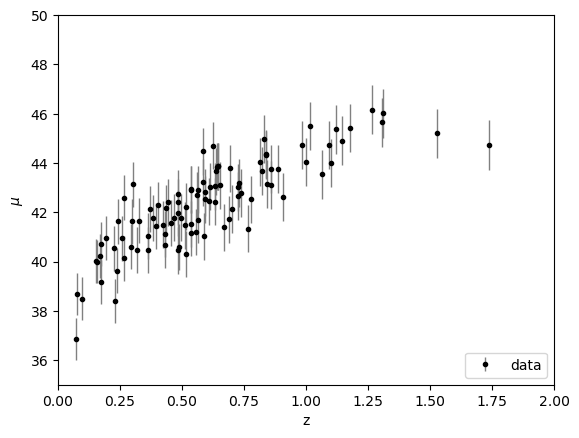

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


Linear fit:  slope = 4.764,  intercept = 39.484


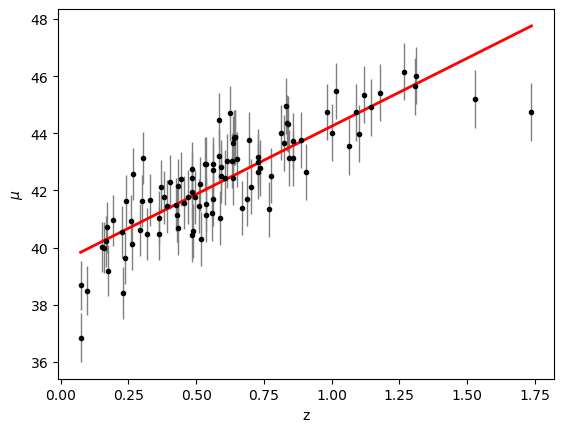

In [11]:
#start with linear regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

x = z_sample[:, np.newaxis]
y = mu_sample

model = LinearRegression()
weights = 1/dmu**2
model.fit(x, y, sample_weight=weights)

theta0 = model.intercept_
theta1 = model.coef_[0]
print(f'Linear fit:  slope = {theta1:.3f},  intercept = {theta0:.3f}')

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = theta1 * x_fit + theta0

plt.figure()
plt.errorbar(x, y, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(x_fit, y_fit, 'r-', lw=2, label=f'Linear fit (d=1)')
plt.xlabel(r'z')
plt.ylabel(r'$\mu$')
plt.show()



[42.38034994]
[39.56505555  4.64711848]
[38.44821027  8.49035585 -2.57760572]
[38.49130243  8.23905057 -2.20391808 -0.15168104]
[ 37.0543994   20.74217865 -32.83020744  27.30599762  -7.98337391]
[ 36.18760445  31.00142053 -69.82397489  82.84185044 -44.24104125
   8.47059008]
[  35.52810145   41.0777603  -119.2923833   190.65950213 -159.23341791
   67.07109508  -11.37900289]
[   33.0388866     88.36455436  -419.10465978  1070.05460078
 -1505.50746677  1174.27289713  -473.67088511    76.75032208]
[  33.50565858   77.89342065 -337.63347914  765.4161251  -882.60407239
  442.01979981   18.73687926  -98.85713123   25.70456796]
[   35.26610351    32.52717373    84.29772055 -1185.19631674
  4221.8203542  -7581.90261829  7725.37966027 -4516.73127761
  1411.3078108   -182.6279746 ]


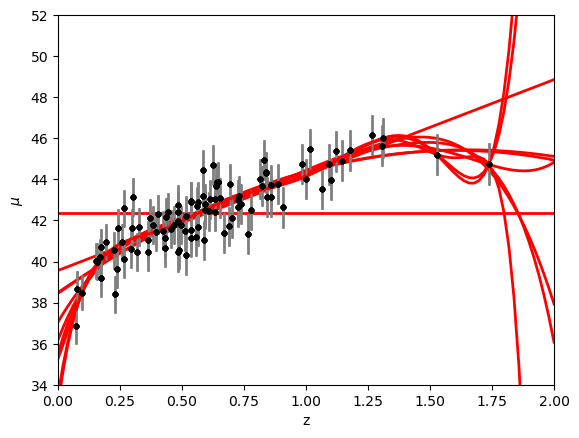

In [28]:
#now lets do the polynomial regression 

from astroML.linear_model import PolynomialRegression

z_test = np.linspace(0, 2, 100)

number_of_degrees = 10 

for i in range(number_of_degrees):
    degree = i
    model = PolynomialRegression(degree) # fit 3rd degree polynomial
    model.fit(z_sample[:, np.newaxis], mu_sample)

    y_pred = model.predict(z_test[:, np.newaxis])
    n_constraints = degree + 1

    print(model.coef_)

    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
    plt.plot(z_test, y_pred, 'r-', lw=2, label=f'Polynomial fit (d={degree})')
    plt.xlabel(r'z')
    plt.ylabel(r'$\mu$')
    plt.ylim(34, 52)
    plt.xlim(0, 2)

plt.show()



c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated a

Il grado ottimale stimato dalla Cross-Validation è: 2


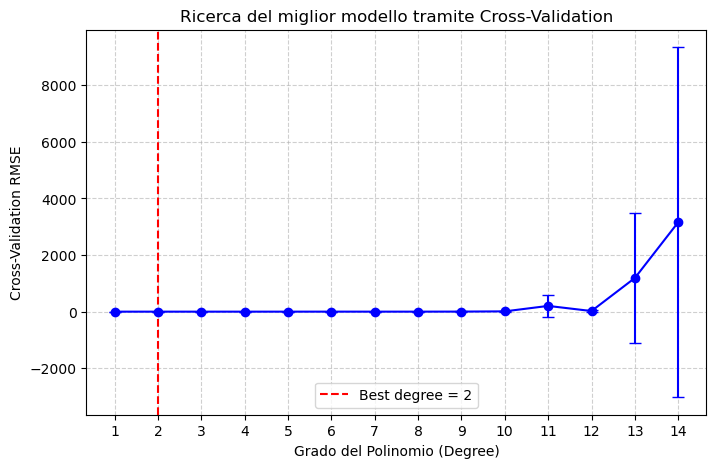

In [33]:
#now lets do the cross validation  

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

x = z_sample[:, np.newaxis]
y = mu_sample
weights = 1.0 / (dmu**2)
degrees = np.arange(1, 15)


cv_scores_mean = []
cv_scores_std = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    
    scores = cross_val_score(model, x, y, cv=5, 
                             scoring='neg_mean_squared_error',
                             fit_params={'linearregression__sample_weight': weights})
    
    rmse_scores = np.sqrt(-scores)
    
    cv_scores_mean.append(np.mean(rmse_scores))
    cv_scores_std.append(np.std(rmse_scores))

cv_scores_mean = np.array(cv_scores_mean)
cv_scores_std = np.array(cv_scores_std)

best_degree = degrees[np.argmin(cv_scores_mean)]
print(f"Il grado ottimale stimato dalla Cross-Validation è: {best_degree}")


plt.figure(figsize=(8, 5))
plt.errorbar(degrees, cv_scores_mean, yerr=cv_scores_std, fmt='-o', color='b', capsize=4)
plt.axvline(best_degree, color='r', linestyle='--', label=f'Best degree = {best_degree}')

plt.xlabel('Grado del Polinomio (Degree)')
plt.ylabel('Cross-Validation RMSE')
plt.title('Ricerca del miglior modello tramite Cross-Validation')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()